<p style='font-size: 24px; font-weight: bold;'>Introduction</p>

<p style='font-size: 18px; font-weight: bold;'>Project Inspiration</p>

It is obvious to anyone that seasonal changes work hand-in-hand with tourism. With Malta being known for its hot sunny climate, it makes for an ideal destination spot for anyone looking for deep-rooted history and culture, traditional architecture, as well as its beautiful beaches.

However, it can also be noted that within the last decade, the number of tourists every summer has sky rocketed. Therefore, I wanted to know exactly WHY this increase has occurred. Is it because of Malta making a bigger name for itself internationally? Or is there another factor?

Upon thinking on this, as a Maltese citizen, it is clear that our summers have gotten drier and hotter, and rather than this deterring tourists, it has brought in an influx of them. Therefore, I wanted concrete correlative data finding the link between these weather conditions and tourists, and whether or not they have as much of an impact as I thought.

In [1]:
import openmeteo_requests
import eurostat

import requests_cache
import pandas as pd
from retry_requests import retry

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Weather Data
# Ensures openmeteo has not been executed already.
try:
    openmeteo
except NameError:
    cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
    retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
    openmeteo = openmeteo_requests.Client(session = retry_session)

# API URL
url = 'https://archive-api.open-meteo.com/v1/archive'
# API parameters
parameters = {
    'latitude': 35.9167,
    'longitude': 14.4333,
    'start_date': '2010-01-01',
    'end_date': '2025-12-31',
    'daily': ['temperature_2m_mean', 'temperature_2m_max', 'apparent_temperature_mean', 'sunshine_duration', 'daylight_duration', 'precipitation_sum', 'wind_speed_10m_max', 'weather_code'],
    'timezone': 'Europe/Berlin',
}

# Retrieval of API responses
responses = openmeteo.weather_api(url, params=parameters)
# Checks if responses were received
if responses:
    response = responses[0]
    daily = response.Daily()

    # Data pulled from response
    weather_data = {
        'mean_temp': daily.Variables(0).ValuesAsNumpy(),
        'max_temp': daily.Variables(1).ValuesAsNumpy(),
        'feels_like': daily.Variables(2).ValuesAsNumpy(),
        'sunshine_dur': daily.Variables(3).ValuesAsNumpy(),
        'daylight_dur': daily.Variables(4).ValuesAsNumpy(),
        'precipitation': daily.Variables(5).ValuesAsNumpy(),
        'wind_speed': daily.Variables(6).ValuesAsNumpy(),
        'weather_code': daily.Variables(7).ValuesAsNumpy()
    }

    # Data fixed into dataframe
    df_weather_raw = pd.DataFrame(weather_data)
    print(df_weather_raw)
else:
    print('No data retrieved from weather api.')


      mean_temp   max_temp  feels_like  sunshine_dur  daylight_dur  \
0     17.038748  18.507500   12.691882  34635.476562  35185.632812   
1     15.326251  16.007500    7.708334  34146.585938  35221.769531   
2     14.495000  15.107500    8.478354  33864.101562  35260.875000   
3     14.947083  16.807501   11.940295  27727.416016  35302.890625   
4     16.984583  18.307501   13.001320  30295.017578  35347.800781   
...         ...        ...         ...           ...           ...   
5839  15.460418  16.700001   12.828908  32277.310547  35051.968750   
5840  14.456249  17.100000   13.398805  33581.242188  35072.425781   
5841  13.739586  16.350000   13.159008  29120.347656  35096.046875   
5842  13.622916  15.400000   11.149653  33344.414062  35122.812500   
5843  13.218750  15.400000   10.697787  32398.789062  35152.710938   

      precipitation  wind_speed  weather_code  
0               0.0   43.601631           2.0  
1               0.2   54.553955          51.0  
2              

In [3]:
# Tourist data
# Retrieval of data using eurostat
df_tourism_raw = eurostat.get_data_df('tour_occ_arm')

# Checks if df_tourism_raw was retrieved
if df_tourism_raw is not None:
    # Mask to filter the Eurostat dataframe to only contain Maltese data
    mask = (df_tourism_raw['geo\\TIME_PERIOD'] == 'MT') & (df_tourism_raw['c_resid'] == 'TOTAL') & (df_tourism_raw['unit'] == 'NR') & (df_tourism_raw['nace_r2'] == 'I551-I553')
    df_tourism_raw = df_tourism_raw[mask]
    
print(df_tourism_raw)

     freq c_resid unit    nace_r2 geo\TIME_PERIOD  1990-01  1990-02  1990-03  \
1469    M   TOTAL   NR  I551-I553              MT      NaN      NaN      NaN   

      1990-04  1990-05  ...   2025-03   2025-04   2025-05   2025-06   2025-07  \
1469      NaN      NaN  ...  227983.0  249503.0  258737.0  252970.0  265532.0   

       2025-08   2025-09   2025-10   2025-11   2025-12  
1469  271574.0  245468.0  283159.0  225437.0  205171.0  

[1 rows x 437 columns]


In [4]:
# Weather Data Cleaning
# Copy of raw dataframe
df_weather = df_weather_raw.copy()

# Sets date index to dataframe
dates = pd.date_range(start='2010-01-01', end='2025-12-31', freq='D')
df_weather.index = dates

# Converts data from daily to monthly using resample to MS (Month Start) and aggregate to use specific summary methodology
df_weather = df_weather.resample('MS').agg({
    'mean_temp': 'mean',
    'max_temp': 'max',
    'feels_like': 'mean',
    'sunshine_dur': 'sum',
    'daylight_dur': 'sum',
    'precipitation': 'sum',
    'wind_speed': 'mean',
    'weather_code': lambda x: x.mode().iloc[0] # As mode is not a set pandas summary methodology (also takes ties into account)
}).astype(float).round(1)

# weather_code should be an integer.
df_weather['weather_code'] = df_weather['weather_code'].astype(int)

# sunlight_dur and daylight_dur should be in hours not seconds.
df_weather['sunshine_dur'] = df_weather['sunshine_dur'] / 3600
df_weather['daylight_dur'] = df_weather['daylight_dur'] / 3600

# Change dataframe index into datetime object
df_weather.index = pd.to_datetime(df_weather.index, format='%Y-%m').to_period('M')

# Weather code (DMO) mapping
wmo_description = {
    0: 'Clear sky',
    1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',
    45: 'Fog', 48: 'Depositing rime fog',
    51: 'Drizzle: Light', 53: 'Drizzle: Moderate', 55: 'Drizzle: Dense',
    61: 'Rain: Slight', 63: 'Rain: Moderate', 65: 'Rain: Heavy',
    80: 'Rain showers: Slight', 81: 'Rain showers: Moderate', 82: 'Rain showers: Violent',
    95: 'Thunderstorm', 96: 'Thunderstorm with slight hail', 99: 'Thunderstorm with heavy hail'
}

df_weather['weather_desc'] = df_weather['weather_code'].map(wmo_description)

print(df_weather)

         mean_temp  max_temp  feels_like  sunshine_dur  daylight_dur  \
2010-01       13.8      18.5         8.9    260.265167    311.249000   
2010-02       13.8      19.0         9.3    261.864583    304.877278   
2010-03       14.4      18.3        11.1    315.765556    371.211167   
2010-04       16.1      19.4        14.2    352.021778    393.318722   
2010-05       18.5      24.2        16.6    385.540556    436.100778   
...            ...       ...         ...           ...           ...   
2025-08       26.5      32.3        29.6    388.778278    417.709333   
2025-09       25.4      32.8        27.9    342.742056    371.717806   
2025-10       21.4      26.9        21.3    309.080611    349.078333   
2025-11       18.1      24.2        17.0    257.064333    308.242917   
2025-12       15.3      20.4        13.7    247.401250    302.839306   

         precipitation  wind_speed  weather_code    weather_desc  
2010-01           56.8        41.5             3        Overcast  
2

In [5]:
# Tourist Data Cleaning
# Copy of raw dataframe
df_tourism = df_tourism_raw.copy()

# Filters dataframe columns to only check past 2010-01
df_tourism = df_tourism.loc[:, '2010-01':]

# Flip dataframe to retrieve values as rows (matches weather dataframe)
df_tourism = df_tourism.T

# Converts index to datetime object
df_tourism.index = pd.to_datetime(df_tourism.index, format='%Y-%m').to_period('M')

# Changes column name
df_tourism.columns = ['tourist_arrivals']

# Turns all values into integers (since tourist amount if discrete)
df_tourism = df_tourism.astype(int)

print(df_tourism)

         tourist_arrivals
2010-01             49634
2010-02             65960
2010-03             84836
2010-04            104939
2010-05            123745
...                   ...
2025-08            271574
2025-09            245468
2025-10            283159
2025-11            225437
2025-12            205171

[192 rows x 1 columns]


In [6]:
# Merging of Dataframes
df_combined = pd.concat([df_tourism, df_weather], axis=1)

print(df_combined)

         tourist_arrivals  mean_temp  max_temp  feels_like  sunshine_dur  \
2010-01             49634       13.8      18.5         8.9    260.265167   
2010-02             65960       13.8      19.0         9.3    261.864583   
2010-03             84836       14.4      18.3        11.1    315.765556   
2010-04            104939       16.1      19.4        14.2    352.021778   
2010-05            123745       18.5      24.2        16.6    385.540556   
...                   ...        ...       ...         ...           ...   
2025-08            271574       26.5      32.3        29.6    388.778278   
2025-09            245468       25.4      32.8        27.9    342.742056   
2025-10            283159       21.4      26.9        21.3    309.080611   
2025-11            225437       18.1      24.2        17.0    257.064333   
2025-12            205171       15.3      20.4        13.7    247.401250   

         daylight_dur  precipitation  wind_speed  weather_code    weather_desc  
2010-0

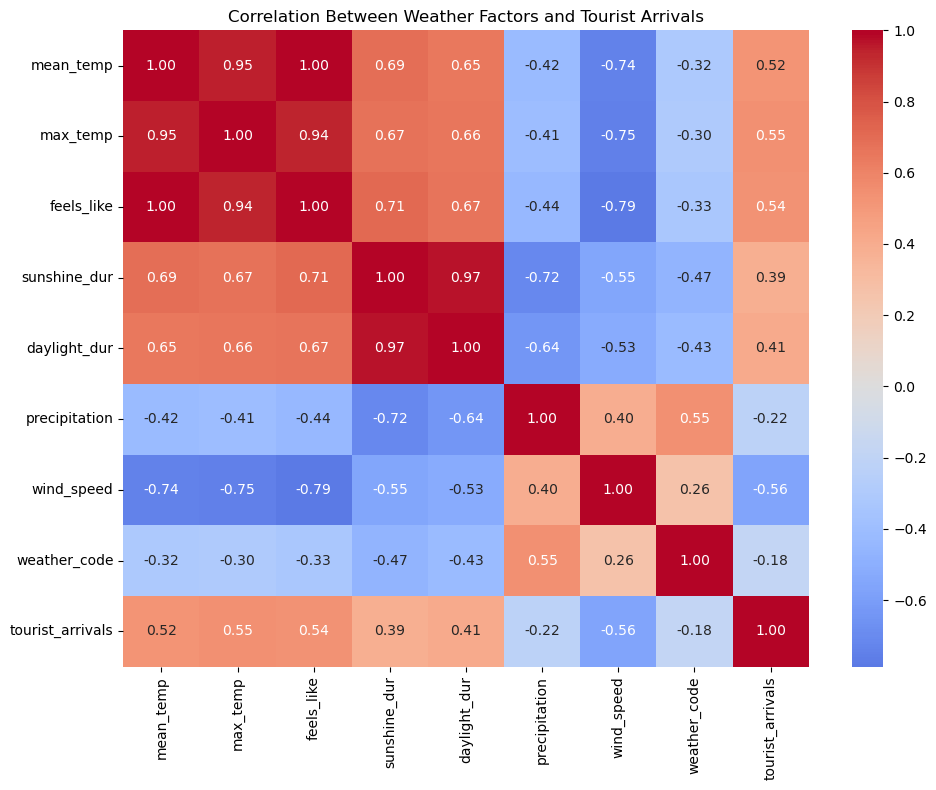


=== CORRELATION RESULTS ===

max_temp         0.545711
feels_like       0.538592
mean_temp        0.522004
daylight_dur     0.412368
sunshine_dur     0.389575
weather_code    -0.183398
precipitation   -0.219018
wind_speed      -0.557043
Name: tourist_arrivals, dtype: float64

=== LASSO REGRESSION RESULTS ===

         feature   coefficient
0      mean_temp   9978.151278
2   daylight_dur   5888.161859
3  precipitation   1864.190713
1   sunshine_dur     -0.000000
5   weather_code     -0.000000
4     wind_speed -20417.979910


sunshine_dur  has been dropped by Lasso.
weather_code  has been dropped by Lasso.

Precipitation Stats

 count    192.000000
mean      32.660937
std       34.883058
min        0.000000
25%        3.300000
50%       23.250000
75%       50.500000
max      164.700000
Name: precipitation, dtype: float64


In [7]:
# Use of Lasso Regression to identify feature importance
# Correlation visualisation via Correlation Matrix
weather_features = ['mean_temp', 'max_temp', 'feels_like', 'sunshine_dur', 'daylight_dur', 'precipitation', 'wind_speed', 'weather_code']

# Compute correlation
corr = df_combined[weather_features + ['tourist_arrivals']].corr()#

# Show visualisation
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Weather Factors and Tourist Arrivals')
plt.tight_layout()
plt.show()

# Show list of correlations
print('\n=== CORRELATION RESULTS ===\n')
print(corr['tourist_arrivals'].drop('tourist_arrivals').sort_values(ascending=False))

# Due to the high correlation between the 3 temperature values, mean_temp will be taken as a representative value.
weather_features = ['mean_temp', 'sunshine_dur', 'daylight_dur', 'precipitation', 'wind_speed', 'weather_code']

# Lasso Regression Model to verify significance of these features
X = df_combined[weather_features]
y = df_combined['tourist_arrivals']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature': weather_features,
    'coefficient': lasso.coef_
}).sort_values('coefficient', ascending=False)

print('\n=== LASSO REGRESSION RESULTS ===\n')
print(coef_df)

print('\n')

# Result analysis
dropped = coef_df[coef_df['coefficient'] == 0.0]['feature'].tolist()

for item in dropped:
    weather_features.remove(item)
    print(item, ' has been dropped by Lasso.')

# Investigating anomolous result
print('\nPrecipitation Stats\n\n', df_combined['precipitation'].describe())

weather_features.remove('precipitation')

<p style='font-size: 24px; font-weight: bold;'>Result Analysis</p>

<p style='font-size: 18px; font-weight: bold;'>Positive Trend Indicators</p>

1. mean_temp

The strongest positive trend indicator was the 'mean_temp' feature, showing that approximately 10,000 more tourists come to Malta when temperatures are higher.

2. daylight_dur

The second strongest positive trend indicator was 'daylight_dur'. This shows that the duration of daylight is more influencial than the duration of sunshine.

3. precipitation

A surprising 'positive' trend indicator. This was deemed anomolous due to the illogical coefficient *(more rain bringing more tourists)* and its weak influence.

After analysing the stats of precipitation, it was determined that there was not enough variance to determine a reasonable positive influence, which is why precipitation was dropped.

<p style='font-size: 18px; font-weight: bold;'>Impactless Features</p>

'sunshine_dur' and 'weather_code' were both dropped as the Lasso Regression model determined that neither of these features influence the number of tourists.

<p style='font-size: 18px; font-weight: bold;'>Negative Trend Indicators</p>
1. wind_speed

While being the only negative indicator, it had the largest influence on tourists. Approximately 20,000 less tourists visited Malta when weather featured strong winds.

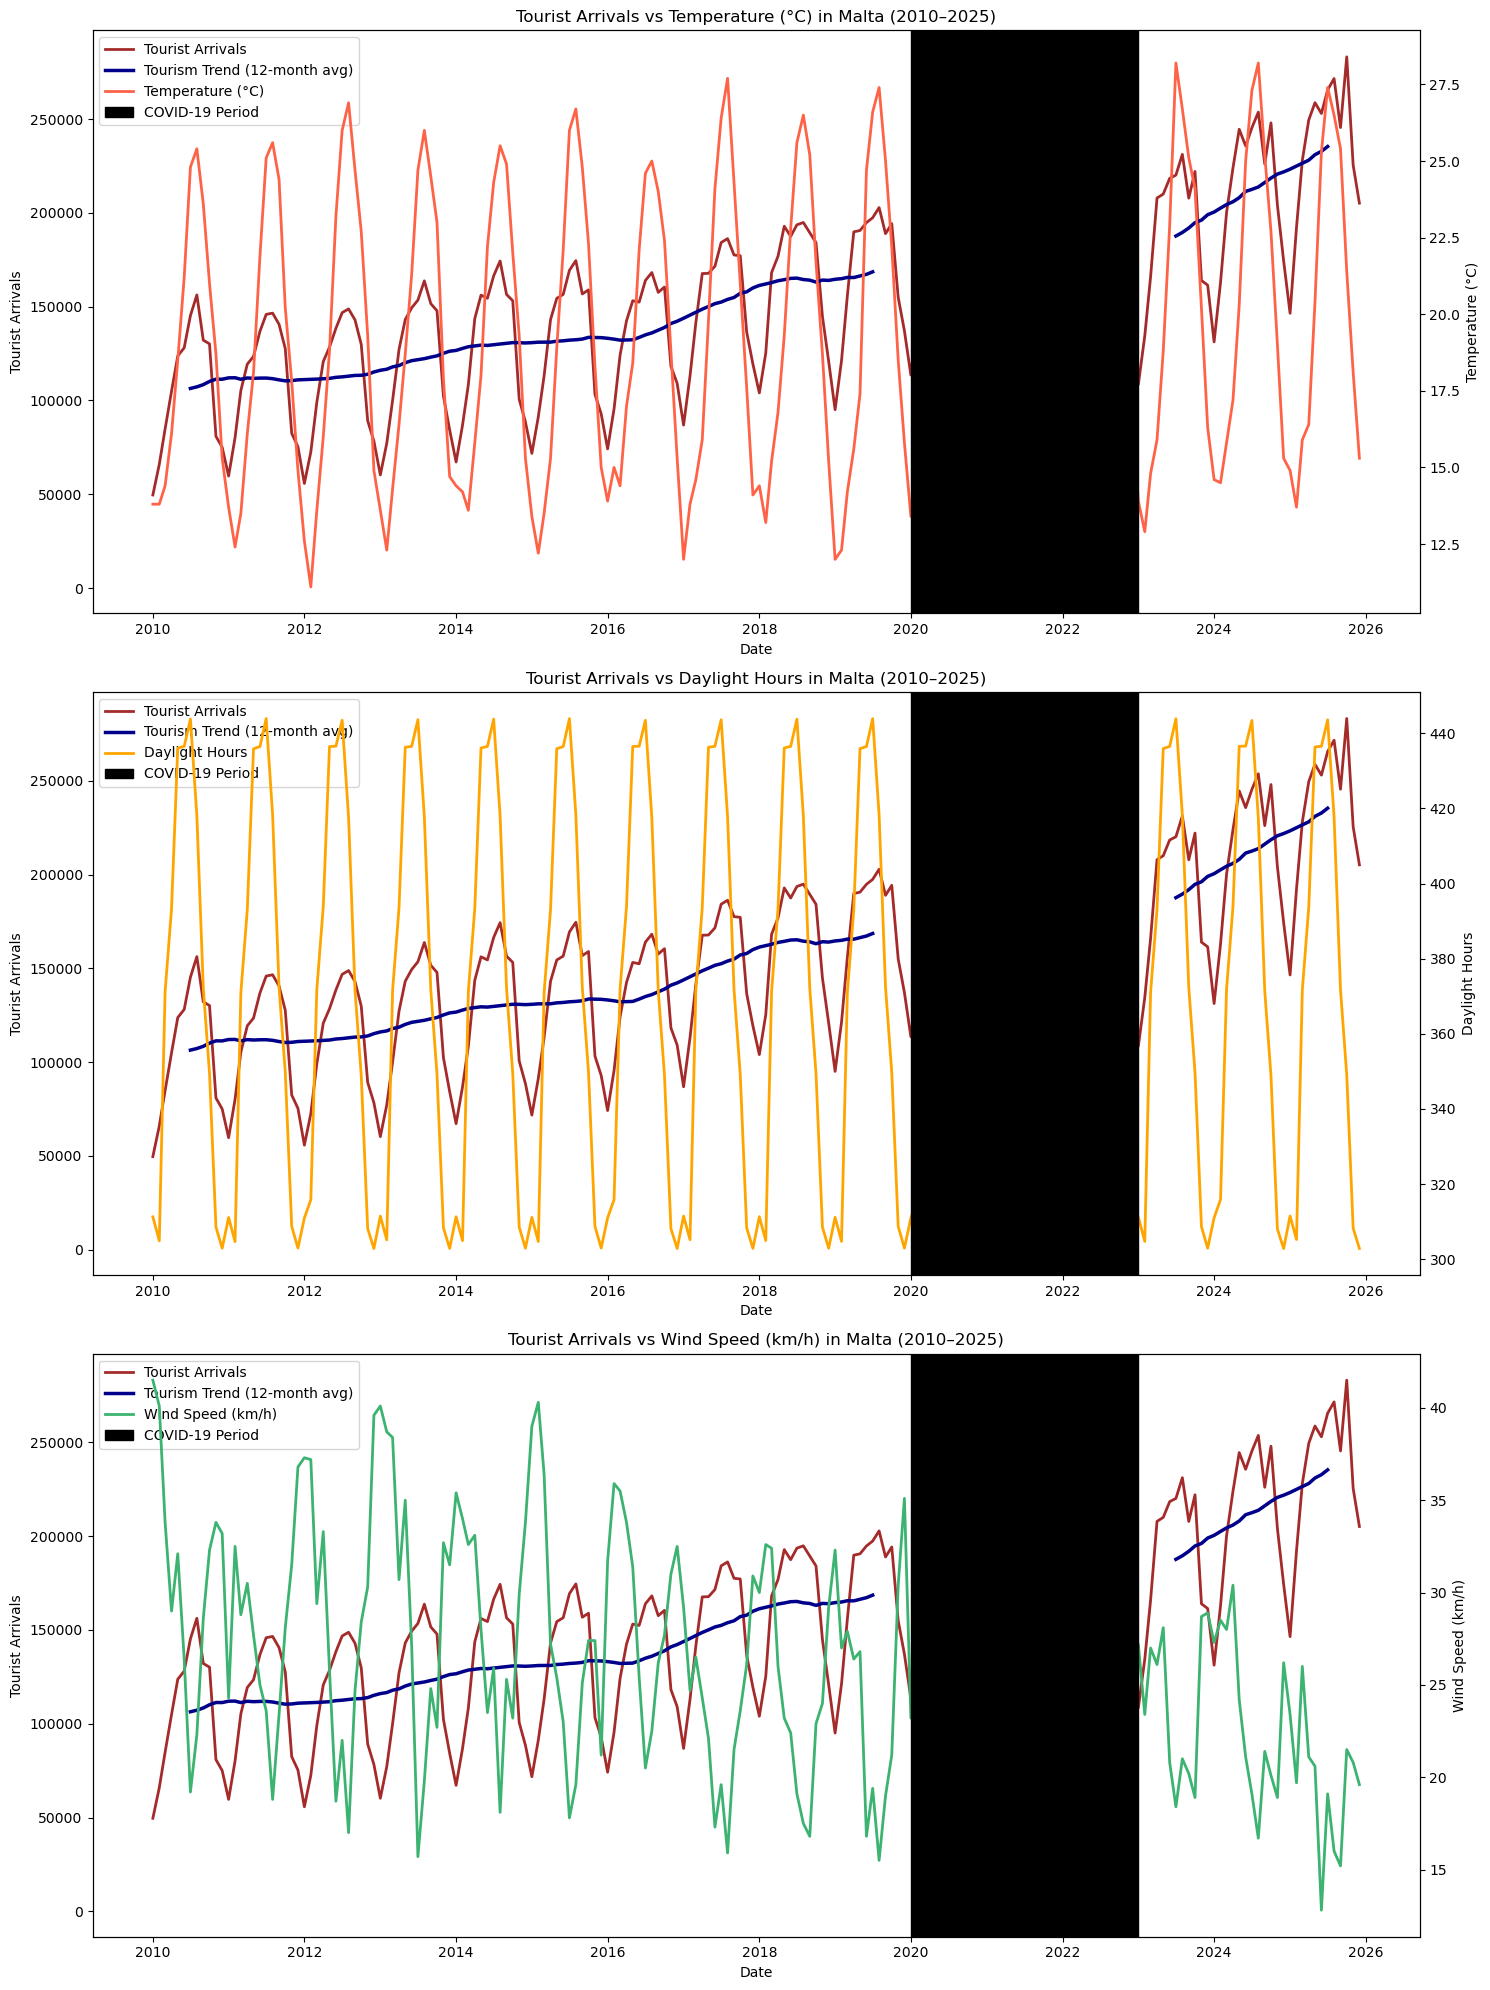

In [8]:
# Dual-axis line plots representing trends
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

# Rewriting over weather_features to include units and colours for suitable graph plotting
weather_features = {
    'mean_temp': ('Temperature (°C)', 'tomato'),
    'daylight_dur': ('Daylight Hours', 'orange'),
    'wind_speed': ('Wind Speed (km/h)', 'mediumseagreen')
}

for ax1, (feature, (ylabel, color)) in zip(axes, weather_features.items()):
    # Tourist arrivals on left axis
    ax1.plot(df_combined.index.to_timestamp(), df_combined['tourist_arrivals'], color='brown', label='Tourist Arrivals', linewidth=2)
    
    # 12-month rolling trend
    trend = df_combined['tourist_arrivals'].copy()
    trend[pd.Timestamp('2020-01-01'):pd.Timestamp('2022-12-31')] = np.nan
    trend = trend.rolling(window=12, center=True).mean()
    ax1.plot(df_combined.index.to_timestamp(), trend, color='darkblue', label='Tourism Trend (12-month avg)', linewidth=2.5)
    
    ax1.set_ylabel('Tourist Arrivals')
    ax1.tick_params(axis='y')
    ax1.set_xlabel('Date')

    # Weather feature on right axis
    ax2 = ax1.twinx()
    ax2.plot(df_combined.index.to_timestamp(), df_combined[feature], color=color, label=ylabel, linewidth=2)
    ax2.set_ylabel(ylabel)
    ax2.tick_params(axis='y')

    # Block to cover COVID-19 period due to anomolous data
    ax2.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2022-12-31'), color='black', label='COVID-19 Period', zorder=20)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title(f'Tourist Arrivals vs {ylabel} in Malta (2010–2025)')

plt.tight_layout()
plt.show()

<p style='font-size: 24px; font-weight: bold;'>Result Analysis</p>

<p style='font-size: 18px; font-weight: bold;'>Noticeable Considerations</p>

**2020 - 2022 Tourism Dip**

Data from the 2020-2022 period was excluded from this visualisation to account for the tourism dip due to the COVID-19 pandemic. Removing this anomaly ensures that the visualisation remains consistent with long-term trends and consumer sentiment.

<p style='font-size: 18px; font-weight: bold;'>Expected Results</p>

**mean_temp** and **daylight_hours** both provided the expected results. During colder months containing less daylight hours, tourism has a noticeable dip. This aligns with the preconceived notion of tourism peaking during the summer. Both of these features move proportionally with the **Tourist Arrivals**, confirming the positive coefficient made by the Lasso Regression model earlier on.

<p style='font-size: 18px; font-weight: bold;'>Unexpected Results</p>

Alternatively, **wind_speed** shows a decline over this time period, sparking doubts regarding potential data inaccuracies. As Malta becomes an increasingly more popular tourist attraction over the years, there are 2 possible scenarios to be looked into:

1. **Data Measurement Inaccuracies**

This scenario implies that either changes in measurement methodology or data source rather than a genuine meteorological trend, supported by the structural break in between 2016 and 2018, which clearly shows that this is not a gradual decline caused by climate change. Furthermore, implying that this extreme negative correlation trend is purely coincidental (as wind speed decreased due to these inaccuracies, Malta's popularity rose - displaying an inversely proportional relationship). 

2. **Underlying Correlation**

This scenario is strengthened by the Lasso Regression Coefficient of -20,418, the strongest coefficient in the model, suggesting that statistically, wind speed has a strong statisitical influence on **tourist_arrivals**. Hence, it shows that **wind_speed** is a feature that is often overlooked, indicating that the decreasing wind speeds made Malta more attractive for tourists to visit.

In [9]:
# Search Analysis Dataframe + Cleaning
# Importing csv file
df_searches_raw = pd.read_csv('malta_search_history_raw.csv')
df_searches = df_searches_raw

# Fixing dataframe to contain date with aligning format in index
df_searches['Time'] = pd.to_datetime(df_searches['Time'], format='%Y-%m-%d')
df_searches.index = df_searches['Time'].dt.to_period('M')
df_searches.index.name = None

# Filtering of irrelevant row and column
df_searches = df_searches.loc[:, 'malta travel':]
df_searches = df_searches.drop(df_searches.index[0])

print(df_searches)

# Saving cleaned CSV file
df_searches.to_csv('malta_search_history_cleaned.csv')

         malta travel
2010-01            46
2010-02            31
2010-03            42
2010-04            55
2010-05            42
...               ...
2025-08            34
2025-09            22
2025-10            23
2025-11            27
2025-12            33

[192 rows x 1 columns]


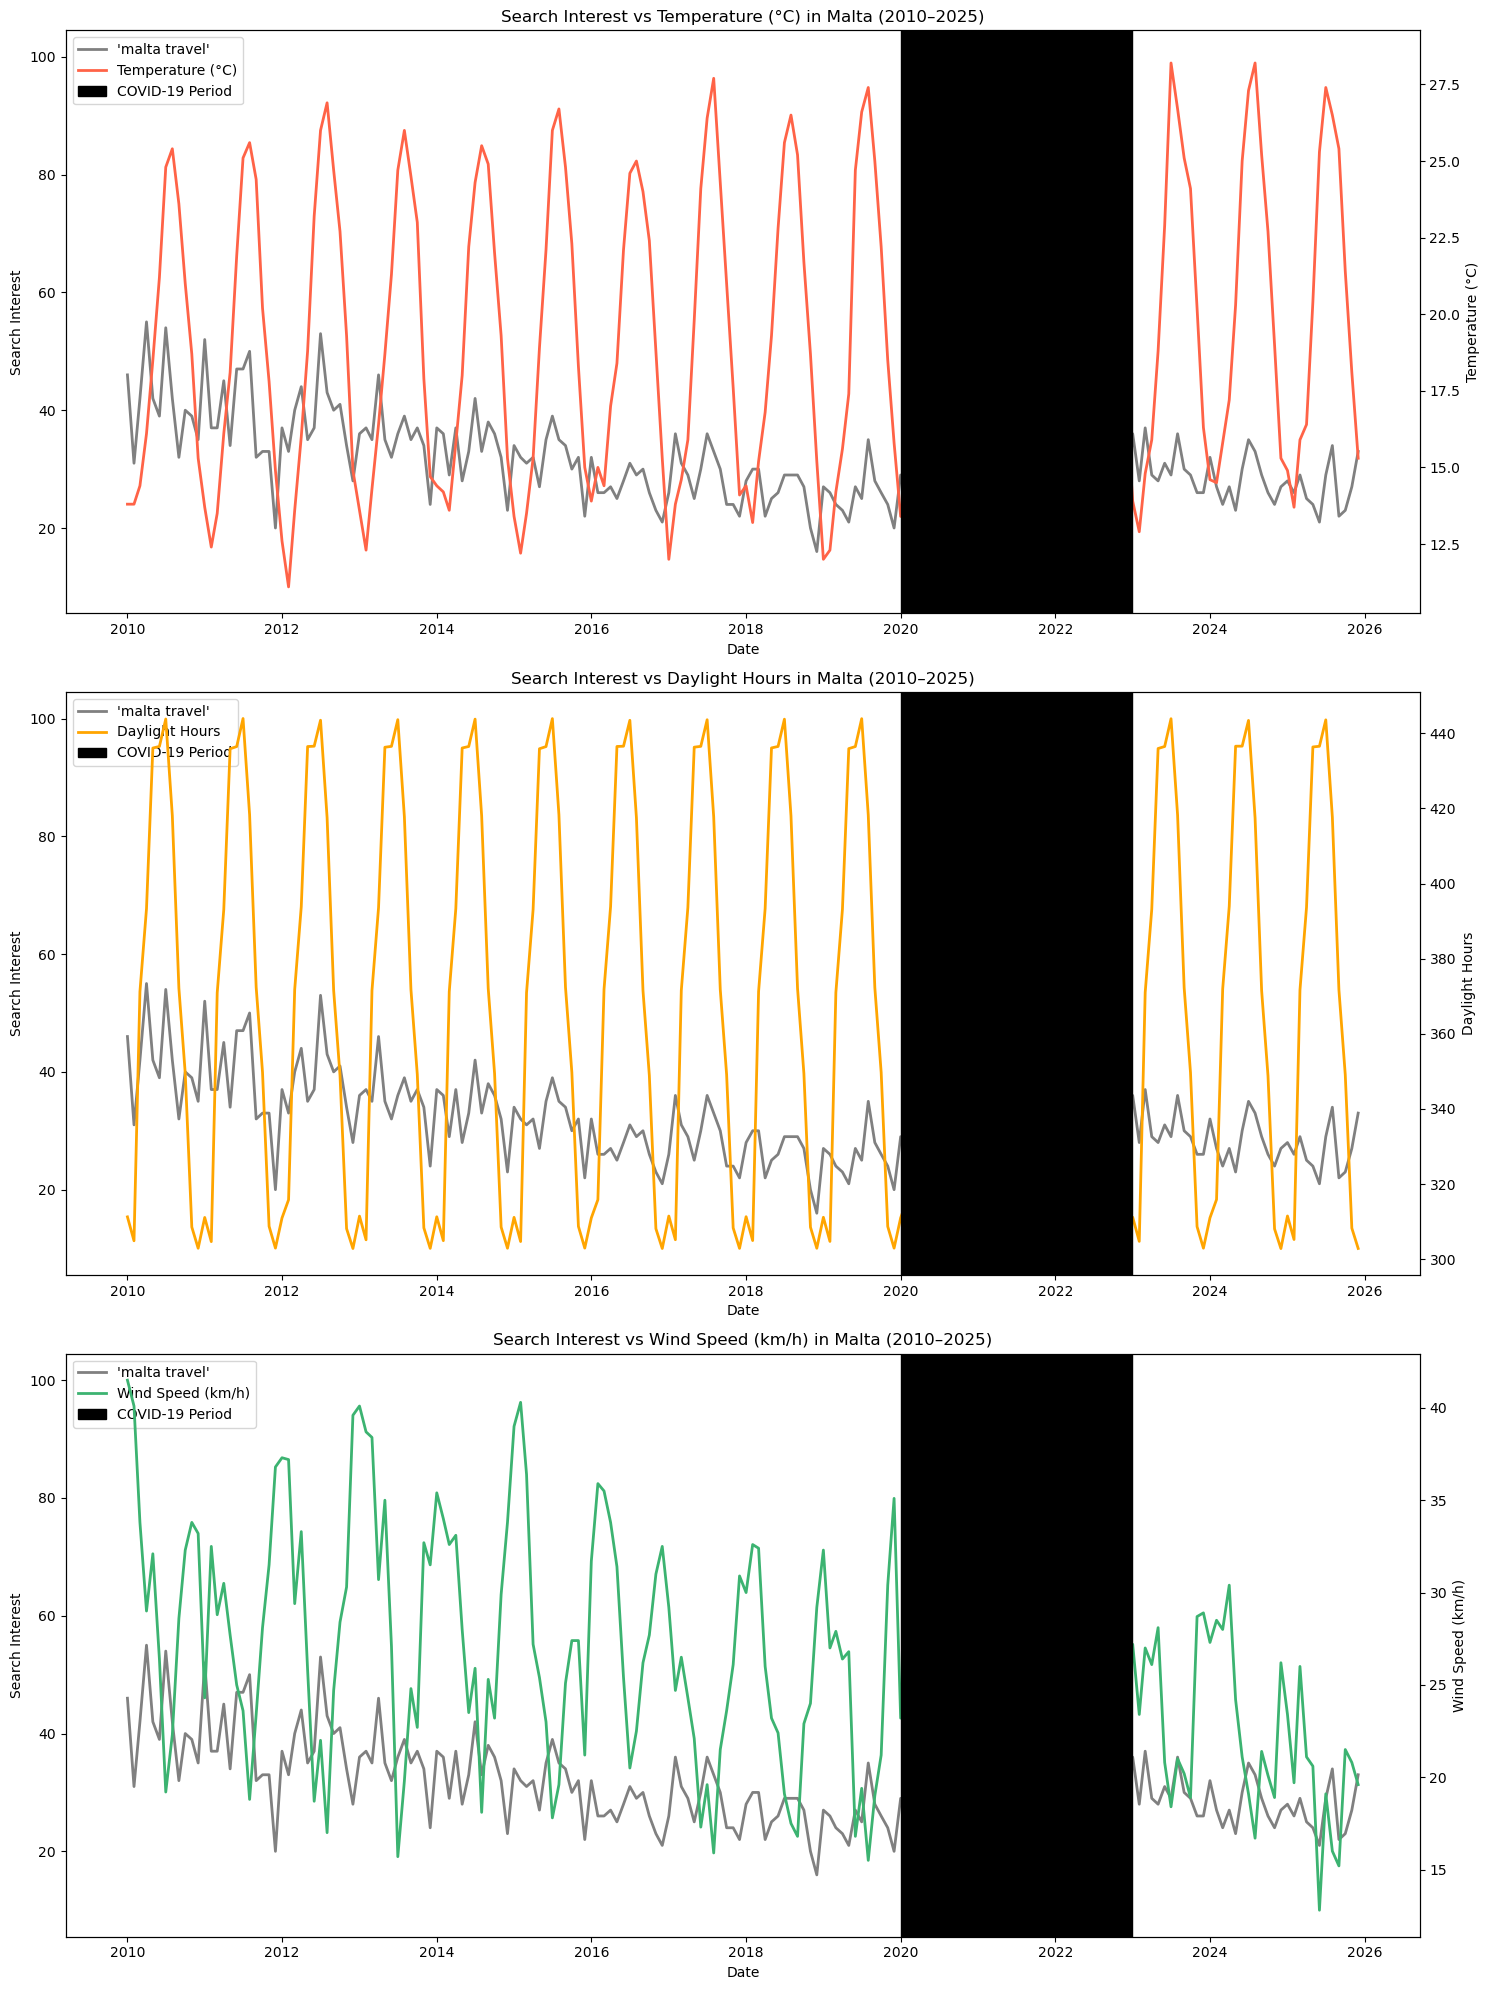

In [10]:
# Visualisation of Search Variables vs Prominent Weather Features
fig, axes = plt.subplots(3, 1, figsize=(15, 20))
for ax1, (feature, (ylabel, color)) in zip(axes, weather_features.items()):
    # Search Interest on left axis
    ax1.plot(df_searches.index.to_timestamp(), df_searches['malta travel'], color='gray', label='\'malta travel\'', linewidth=2)
    ax1.set_ylabel('Search Interest')
    ax1.tick_params(axis='y')
    ax1.set_xlabel('Date')

    # Weather feature on right axis
    ax2 = ax1.twinx()
    ax2.plot(df_combined.index.to_timestamp(), df_combined[feature], color=color, label=ylabel, linewidth=2, zorder=10)
    ax2.set_ylabel(ylabel)
    ax2.tick_params(axis='y')

    # Block to cover COVID-19 period due to anomolous data
    ax2.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2022-12-31'), color='black', label='COVID-19 Period', zorder=20)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title(f'Search Interest vs {ylabel} in Malta (2010–2025)')

plt.tight_layout()
plt.show()

<p style='font-size: 24px; font-weight: bold;'>Result Analysis</p>

It can be observed that the **Search Interest** follows the trend of **Number of Tourists**. Notably, search interest begins peaking slightly before the start of the hot weather, suggesting that the intent to travel comes before the actual tourist season. This reinforces the notion that weather is a direct driver of tourism demand.

However, **Search Interest** remains relatively consistent throughout the timeframe, with no noticeable long-term surges. This suggests that it captures seasonal patterns, rather than growing popularity.

This pattern remains consistent across both the **temperature** and **daylight duration**, both of which increase proportionally with the search interest. Alternatively, **wind speed** moves inversely to the search interest, which remains consistent with the negative correlation identified in earlier findings.

<p style='font-size: 24px; font-weight: bold;'>Conclusions</p>

Overall, the analysis suggests that weather conditions, particularly **temperature** and **daylight hours**, play a significant role in Malta's tourism patterns, with warmer sunnier months consistently attracting higher visitor numbers. This is further reinforced by Google Trends data, which shows search interest in Malta travel peaking slightly before the start of the warmer weather, suggesting that weather anticipation is a direct contributing factor during travel planning. The features **temperature** and **daylight hours** show consistent recordings throughout the years, and clear and consistent correlation patterns relative to the number of tourists. On the other hand, **wind speed** has the potential to be a deciding factor in tourist arrivals *if and only if* the data can be confirmed to be accurate.